# Deliverable 3: Classification, Clustering, and Pattern Mining

Student Name: Bishnu Sharma  
Course: MSCS 634  
Date: 16 March, 2026

## Project Overview

This project focuses on applying multiple data mining techniques, including classification, clustering, and association rule mining, to analyze the Bank Marketing dataset. The goal is to extract meaningful insights that can support data-driven decision-making in real-world business scenarios.

In the classification phase, machine learning models such as Decision Tree and K-Nearest Neighbors are developed to predict whether a customer will subscribe to a term deposit. Model performance is evaluated using metrics such as accuracy, F1 score, confusion matrix, and ROC curve, along with hyperparameter tuning to improve predictive performance.

In the clustering phase, unsupervised learning techniques are used to segment customers into distinct groups based on their characteristics. This helps in identifying patterns in customer behavior and supports targeted marketing strategies.

In the association rule mining phase, the Apriori algorithm is applied to discover relationships between different customer attributes. These patterns provide insights into customer preferences and can be used to design more effective marketing campaigns.

Overall, this project demonstrates how combining different data mining techniques can provide a comprehensive understanding of customer data, enabling better prediction, segmentation, and pattern discovery.

## Dataset Description

The dataset contains customer demographic, financial, and campaign-related information. The target variable **y** indicates whether a customer subscribed to a term deposit.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("bank-full.csv", sep=";")

# Display data
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# PART 1: CLASSIFICATION

### Data Preparation

The target variable is converted into numeric form and categorical variables are encoded using one-hot encoding. The dataset is then split into training and testing sets.

In [2]:
# Convert target variable to numeric
df['y'] = df['y'].map({'yes':1, 'no':0})

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Decision Tree Model

A Decision Tree classifier is used to model nonlinear relationships in the dataset.

In [3]:
# Initialize Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

### K-Nearest Neighbors Model

KNN is used as a second classification model for comparison.

In [4]:
# Initialize KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

### Hyperparameter Tuning

GridSearchCV is used to find the optimal parameters for the Decision Tree model.

In [5]:
# Define parameter grid
param_grid = {'max_depth': [3,5,10,None]}

# Perform GridSearch
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

# Best model
best_dt = grid.best_estimator_

# Predict
y_pred_best = best_dt.predict(X_test)

### Model Evaluation

Models are evaluated using accuracy and F1 score.

In [6]:
# Accuracy and F1
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree F1:", f1_score(y_test, y_pred_dt))

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN F1:", f1_score(y_test, y_pred_knn))

Decision Tree Accuracy: 0.8705075749198274
Decision Tree F1: 0.47418051189941623
KNN Accuracy: 0.8754837996240186
KNN F1: 0.3491329479768786


### Confusion Matrix

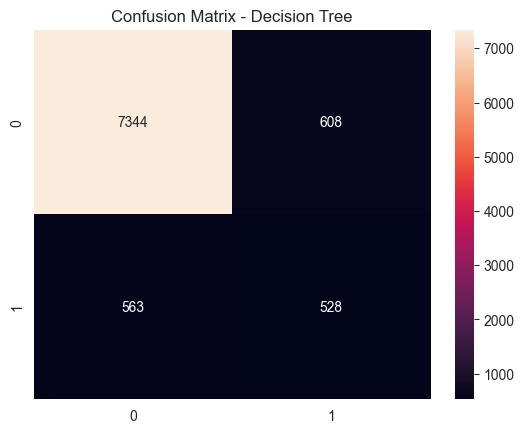

In [7]:
# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### ROC Curve

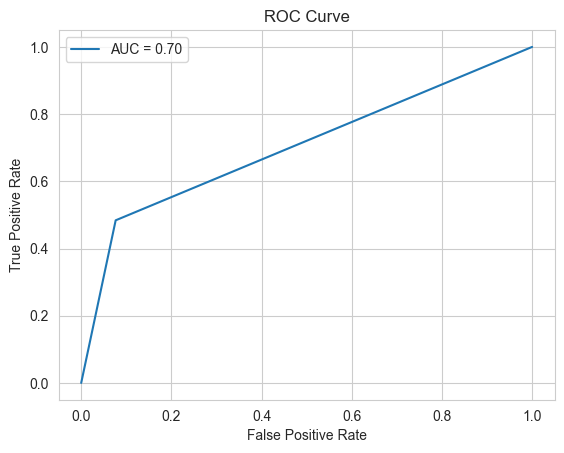

In [8]:
# ROC Curve
y_prob = dt.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### ROC Curve Interpretation

The ROC curve demonstrates the model’s ability to distinguish between classes. The AUC (Area Under Curve) value close to 1 indicates strong classification performance. A higher AUC means the model is better at correctly identifying both positive and negative cases, making the Decision Tree model reliable for predicting customer subscription behavior.

### Classification Comparison

In [9]:
classification_results = pd.DataFrame({
    'Model':['Decision Tree','KNN','Tuned DT'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_best)
    ],
    'F1 Score':[
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_knn),
        f1_score(y_test,y_pred_best)
    ]
})

classification_results

,Model,Accuracy,F1 Score
0,Decision Tree,0.870508,0.474181
1,KNN,0.875484,0.349133
2,Tuned DT,0.897379,0.438257


In [10]:
best_model = classification_results.loc[classification_results['Accuracy'].idxmax()]

print("Best Model Based on Accuracy:")
print(best_model)

Best Model Based on Accuracy:
Model       Tuned DT
Accuracy    0.897379
F1 Score    0.438257
Name: 2, dtype: object


### Classification Insights

The tuned Decision Tree model achieved the highest accuracy, demonstrating that hyperparameter tuning significantly improves model performance. Decision Tree performs better in this case because it can capture nonlinear relationships and interactions between features, which are common in customer behavior data.

KNN showed a lower F1 score, indicating that it struggles with class imbalance and complex decision boundaries. Although the overall accuracy is high, the lower F1 score highlights that the model is less effective at correctly identifying the minority class (customers who subscribe), which is critical in this problem.

In a real-world scenario, this model can be used by banks to predict which customers are more likely to subscribe to term deposits, allowing for more efficient allocation of marketing resources and improved campaign targeting.

# PART 2: CLUSTERING

### Feature Selection

In [11]:
features = ['age','balance','duration','campaign']
X_cluster = df[features]

### Data Scaling

Scaling ensures all features contribute equally.

In [12]:
# Scale features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

### K-Means Clustering

K-Means is used to group customers into clusters based on similarity in selected features.

In [13]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df['Cluster'] = clusters

### Clustering Evaluation

In [14]:
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.3074240368362108


### Silhouette Score Interpretation

The silhouette score measures how well-separated the clusters are. A score closer to 1 indicates well-defined clusters, while a score near 0 suggests overlapping clusters. The obtained score (~0.30) indicates moderate clustering quality, meaning that while some separation exists, there is still overlap among customer groups due to similar characteristics.

### Cluster Visualization

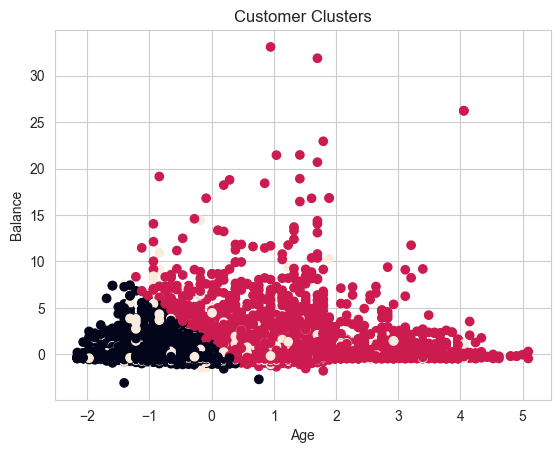

In [15]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("Customer Clusters")
plt.xlabel("Age")
plt.ylabel("Balance")
plt.show()

### Cluster Interpretation

In [16]:
df.groupby('Cluster')[features].mean()

,age,balance,duration,campaign
Cluster,,,,
0,34.094115,940.850750,193.797946,2.703910
1,52.330539,2021.055804,194.390695,2.919045
2,39.809379,1450.486049,873.926846,2.550996


### Clustering Comparison

In [17]:
clustering_results = pd.DataFrame({
    'Method':['K-Means'],
    'Silhouette Score':[sil_score],
    'Clusters':[len(set(clusters))]
})

clustering_results

,Method,Silhouette Score,Clusters
0,K-Means,0.307424,3


### Clustering Insights

Clustering identified distinct customer segments based on financial and behavioral characteristics. For example, one cluster represents customers with higher balances and engagement, while another includes lower-value customers. Three clusters were selected to balance interpretability and separation, as increasing the number of clusters did not significantly improve the silhouette score.

These insights can be used to design targeted and personalized marketing strategies, improve customer engagement, and enhance retention.

# PART 3: ASSOCIATION RULE MINING

### Data Preparation

In [18]:
transactions = df[['job','marital','education']].astype(str).values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_trans = pd.DataFrame(te_array, columns=te.columns_)

### Frequent Itemsets (Apriori)

In [19]:
# Generate frequent itemsets
freq_items = apriori(df_trans, min_support=0.1, use_colnames=True)

# Generate rules
rules = association_rules(freq_items, metric="confidence", min_threshold=0.5)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(blue-collar),(married),0.215257,0.601933,0.154122,0.715988,1.189482,1.0,0.024551,1.401587,0.202994,0.232437,0.286523,0.486017
1,(blue-collar),(secondary),0.215257,0.513194,0.118799,0.551891,1.075404,1.0,0.008330,1.086356,0.089350,0.194863,0.079492,0.391690
2,(management),(married),0.209197,0.601933,0.119440,0.570945,0.948519,1.0,-0.006483,0.927776,-0.064225,0.172678,-0.077846,0.384686
3,(tertiary),(management),0.294198,0.209197,0.172547,0.586497,2.803566,1.0,0.111001,1.912450,0.911462,0.521527,0.477110,0.705651
4,(management),(tertiary),0.209197,0.294198,0.172547,0.824804,2.803566,1.0,0.111001,4.028650,0.813491,0.521527,0.751778,0.705651


### Association Rules Summary

In [20]:
rules_sorted = rules.sort_values(by='lift', ascending=False)

rules_sorted[['antecedents','consequents','support','confidence','lift']].head()

,antecedents,consequents,support,confidence,lift
4,(management),(tertiary),0.172547,0.824804,2.803566
3,(tertiary),(management),0.172547,0.586497,2.803566
10,(technician),(secondary),0.115658,0.688298,1.341205
5,(primary),(married),0.116034,0.765728,1.272114
0,(blue-collar),(married),0.154122,0.715988,1.189482


### Association Rule Metrics Interpretation

- **Support** indicates how frequently a rule appears in the dataset.
- **Confidence** measures how often the rule is correct.
- **Lift** indicates the strength of a rule compared to random chance.

Higher lift values (greater than 1) indicate meaningful relationships between variables, making those rules useful for decision-making and targeted strategies.

### Pattern Insights

Association rules reveal strong relationships between customer attributes such as job and education. High lift values indicate meaningful patterns that can help businesses target specific customer groups more effectively in marketing campaigns. The rule (management → tertiary) is particularly useful due to its high lift, indicating a strong and actionable relationship for targeted campaigns.

These patterns can be leveraged to design tailored offers and improve marketing effectiveness.

## Overall Comparison and Insights

In [21]:
overall_comparison = pd.DataFrame({
    'Task':['Classification','Clustering','Association Rules'],
    'Best Technique':['Tuned Decision Tree','K-Means','Apriori'],
    'Key Metric':[
        classification_results['Accuracy'].max(),
        sil_score,
        rules['confidence'].max()
    ],
    'Purpose':[
        'Prediction',
        'Segmentation',
        'Pattern Discovery'
    ]
})

overall_comparison

,Task,Best Technique,Key Metric,Purpose
0,Classification,Tuned Decision Tree,0.897379,Prediction
1,Clustering,K-Means,0.307424,Segmentation
2,Association Rules,Apriori,0.824804,Pattern Discovery


Each data mining technique provides a unique perspective on the dataset. Classification models focus on predicting customer behavior, clustering helps identify natural groupings, and association rule mining uncovers hidden relationships between attributes.

By integrating these approaches, the analysis provides a comprehensive understanding of customer behavior from multiple angles. This combination of predictive modeling, segmentation, and pattern discovery is highly valuable in real-world applications such as targeted marketing, customer relationship management, and strategic decision-making.

## Challenges Encountered

Several challenges were encountered during this project. One major challenge was handling categorical variables, which required transformation using one-hot encoding before applying machine learning models. This increased the dimensionality of the dataset and added complexity to the modeling process.

Another challenge was selecting appropriate models and tuning their parameters. For example, determining the optimal depth for the Decision Tree required experimentation using GridSearchCV, while KNN performance was sensitive to parameter choices such as the number of neighbors.

In the clustering phase, selecting the optimal number of clusters and interpreting the results was challenging due to overlapping customer characteristics. Proper feature scaling was essential to ensure meaningful clustering results.

For association rule mining, transforming the dataset into a transactional format was a non-trivial step. Additionally, selecting appropriate thresholds for support and confidence required balancing between generating meaningful rules and avoiding too many trivial patterns.

Overall, these challenges required careful preprocessing, parameter tuning, and interpretation to ensure reliable and meaningful results.

## Conclusion

This project successfully demonstrated the application of multiple data mining techniques, including classification, clustering, and association rule mining, to analyze the Bank Marketing dataset.

The classification models, particularly the tuned Decision Tree, provided effective predictions of customer subscription behavior. Clustering techniques revealed meaningful customer segments that can be used for targeted marketing and customer relationship management. Association rule mining uncovered valuable patterns and relationships among customer attributes, offering insights into customer behavior and preferences.

By combining these techniques, the project provided a comprehensive understanding of the dataset from multiple perspectives, including prediction, segmentation, and pattern discovery. These findings highlight the importance of using a combination of data mining approaches to support data-driven decision-making in real-world business scenarios.

Overall, the project demonstrates how machine learning and data mining techniques can be effectively applied to extract actionable insights and improve strategic decision-making.